In [1]:
import matplotlib
matplotlib.use("Pdf")
import matplotlib.pyplot as plt
%matplotlib inline


# set matplotlib parameters
params = {'backend': 'ps',
          'axes.labelsize': 13,
          'font.size': 13,
          'legend.fontsize': 13,
          'xtick.labelsize': 13,
          'ytick.labelsize': 13
         }
plt.rcParams.update(params)

import warnings
warnings.filterwarnings("ignore") #ignore some matplotlib warnings

# numpy
import numpy as np

# Tail fitting via the CRM Dyson solver

First we setup a simple Bethe lattice impurity model. Here we use the `delta_interface=True` of the solver, compared to [other tutorials with the Bethe lattice](https://triqs.github.io/cthyb/latest/guide/dmft.html).

In [2]:
from h5 import HDFArchive
from triqs.gf import Gf, iOmega_n, make_gf_from_fourier, make_zero_tail, fit_hermitian_tail, inverse
from triqs.operators import c, c_dag, n
from triqs.gf.descriptors import SemiCircular
from itertools import product

# plotting interface
from triqs.plot.mpl_interface import plt, oplot

from triqs_cthyb.solver import Solver

Starting serial run at: 2024-06-05 20:04:42.989413


In [3]:
# Set up a few parameters
U = 4.0
half_bandwidth = 1.0
chemical_potential = U/2.0
beta = 10
n_cycles = int(1e+6)
length_cycle = 30
warmup = int(1e+4)

# we are using the delta_interface here compared to earlier examples!
S = Solver(beta = beta, gf_struct = [ ('up',1), ('down',1) ], delta_interface=True, n_iw=501, n_tau=5001)


# Initalize the Green's function to a semi circular DOS
S.G_iw << SemiCircular(half_bandwidth)
delta_iw = S.G_iw.copy()
delta_iw.mesh.set_tail_fit_parameters(tail_fraction=0.5, n_tail_max=40, expansion_order=2)

# first moment of delta is 0
known_moments = make_zero_tail(delta_iw['up'], 1)

# prepare non-interacting impurity Hamiltonian
N = sum(n(sp,orb) for sp, orb in [('up', 0), ('down', 0)])
h_loc0 = -chemical_potential*N

# Now do the DMFT loop once
# Compute new S.G0_iw with the self-consistency condition while imposing paramagnetism
g_sym = 0.5 * ( S.G_iw['up'] + S.G_iw['down'] )

G0_iw = S.G_iw['up'].copy()
G0_iw << inverse(iOmega_n + chemical_potential - (half_bandwidth/2.0)**2 * g_sym)

for name, delta in delta_iw:
    delta << (half_bandwidth/2.0)**2 * g_sym

    tail, err = fit_hermitian_tail(delta, known_moments)
    S.Delta_tau[name] << make_gf_from_fourier(delta, S.Delta_tau.mesh, tail).real

# Run the solver without any tail-fitting or legendre measurements
S.solve(h_int = U * n('up',0) * n('down',0),    # Local Hamiltonian
        n_cycles = n_cycles,                    # Number of QMC cycles
        length_cycle = length_cycle,            # Length of a cycle
        n_warmup_cycles = warmup,               # How many warmup cycles
        h_loc0 = h_loc0,                        # non-interacting impurity Hamiltonian
        measure_density_matrix = True,          # measure impurity density matrix for moments
        use_norm_as_weight = True)

print('imp occ: {:2.4f}'.format(S.G_iw.total_density().real))


╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-2*c_dag('down',0)*c('down',0) + -2*c_dag('up',0)*c('up',0) + 4*c_dag('down',0)*c_dag('up',0)*c('up',0)*c('down',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
20:04:43  34% ETA 00:00:00 cycle 3489 of 10000
20:04:43 100% ETA 00:00:00 cycle 9999 of 10000



Accumulating ...
20:04:43   0% ETA 00:00:27 cycle 3637 of 1000000
20:04:45   7% ETA 00:00:25 cycle 75915 of 1000000
20:04:48  16% ETA 00:00:23 cycle 166317 of 1000000
20:04:51  27% ETA 00:00:20 cycle 279034 of 1000000
20:04:55  42% ETA 00:00:16 cycle 420302 of 1000000
20:05:00  59% ETA 00:00:11 cycle 596897 of 1000000
20:05:06  81% ETA 00:00:05 cycle 817910 of 1000000
20:05:11 100% ETA 00:00:00 cycle 999999 of 1000000


[Rank 0] Collect results: Waiting for all mpi-threads to finish accumulating...
[Rank 0] Timings for all measures:
Measure   

In [4]:
# average impurity Green's function:
G_iw_avg = 0.5*(S.G_iw['up']+S.G_iw['down'])
G_tau_avg = 0.5*(S.G_tau['up']+S.G_tau['down'])

# calculate Sigma via standard Dyson equation:
S_iw_dyson = inverse(G0_iw) - inverse(G_iw_avg)

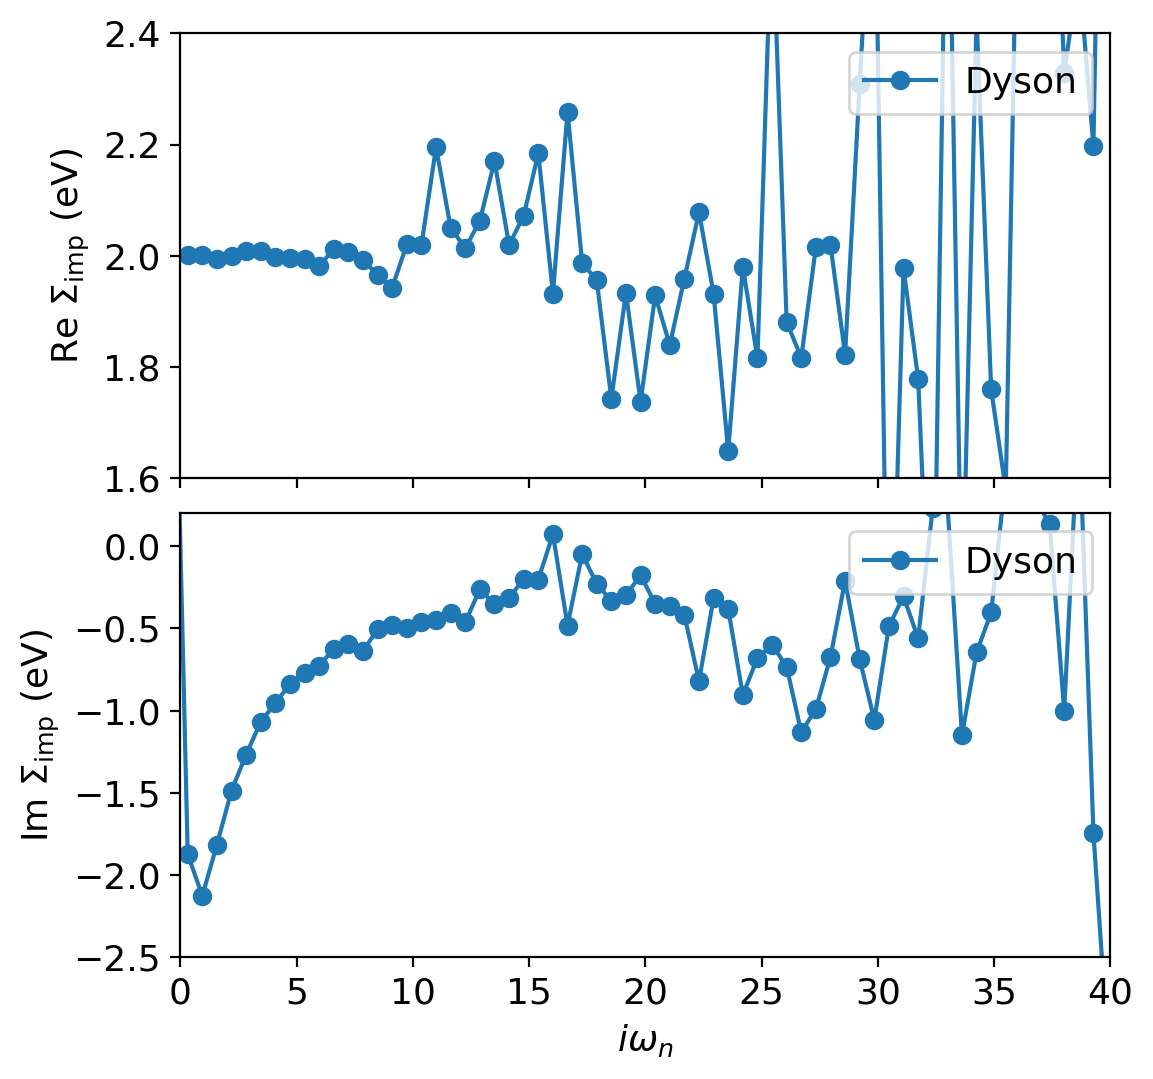

In [5]:
fig, ax = plt.subplots(2,1,dpi=200,figsize=(6,6),sharex=True)
ax = ax.reshape(-1)
fig.subplots_adjust(wspace=0.2, hspace=0.08)


ax[0].oplot(S_iw_dyson.real, '-o', label='Dyson')
ax[1].oplot(S_iw_dyson.imag, '-o', label='Dyson')

ax[0].set_xlim(0,40)
ax[0].set_ylim(1.6,2.4)
ax[1].set_ylim(-2.5,0.2)
ax[0].set_ylabel(r'Re $\Sigma_\mathrm{imp}$ (eV)')
ax[1].set_ylabel(r'Im $\Sigma_\mathrm{imp}$ (eV)')
ax[0].set_xlabel(r'')
ax[1].set_xlabel(r'$i \omega_n$')

plt.show()

## Using the Constrained Residual Minimization Dyson solver

In [6]:
from triqs.gf.dlr_crm_dyson_solver import minimize_dyson
from triqs.gf import fit_gf_dlr, make_gf_dlr_imtime, MeshDLRImFreq, make_gf_imfreq

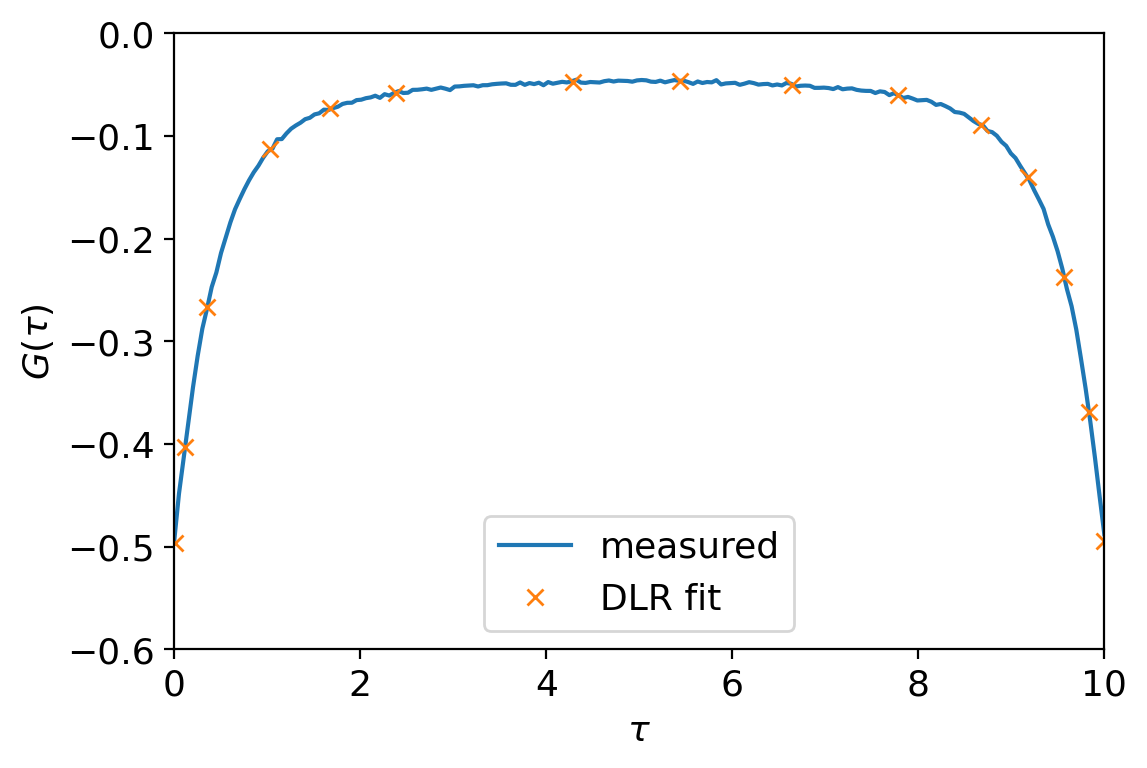

In [7]:
G_dlr_imp = fit_gf_dlr(G_tau_avg, w_max = 2.5, eps = 1e-7)

fig, ax = plt.subplots(1,dpi=200,figsize=(6,4),sharex=True)

ax.oplot(G_tau_avg.rebinning_tau(200).real, '-', label='measured')
ax.oplot(make_gf_dlr_imtime(G_dlr_imp).real, label='DLR fit')

ax.set_xlim(0,beta)
ax.set_ylim(-0.6,0.0)
ax.set_ylabel(r'$G(\tau)$')

ax.set_xlabel(r'$\tau$')
plt.legend(loc='lower center')
plt.show()

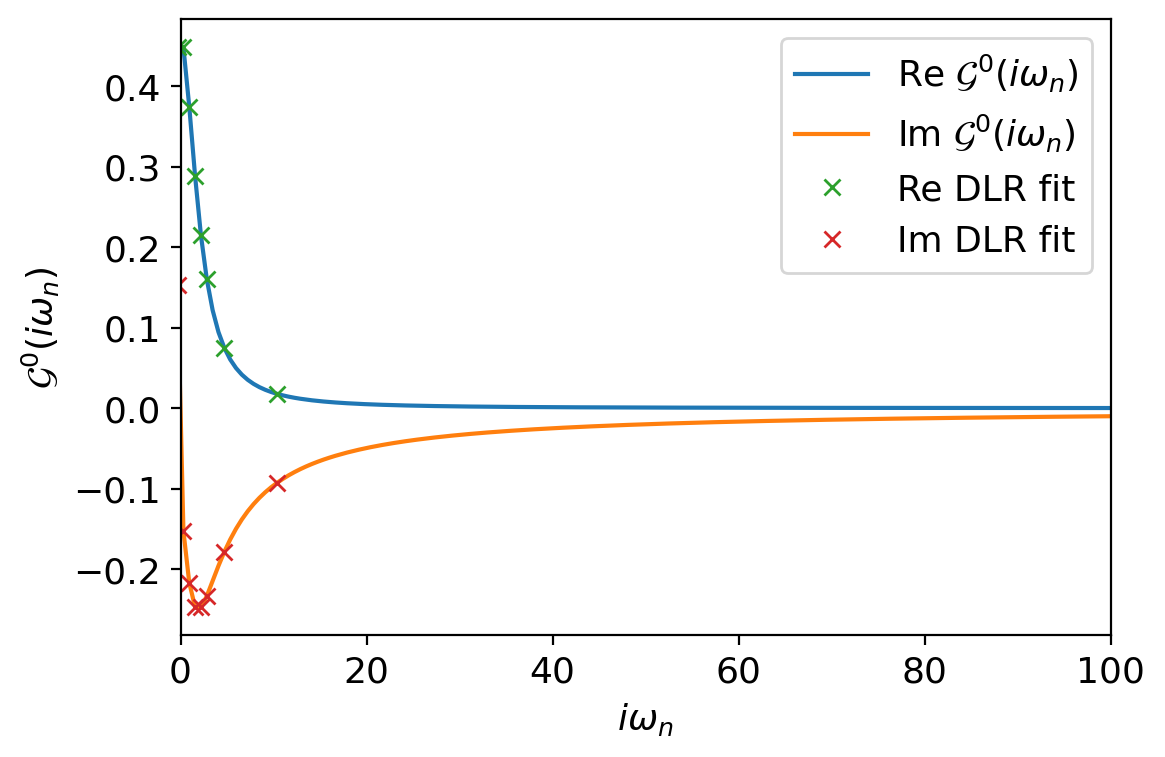

In [8]:
mesh_iw = MeshDLRImFreq(G_dlr_imp.mesh)
G0_dlr_iw = Gf(mesh=mesh_iw, target_shape=G_dlr_imp.target_shape)

for iwn in mesh_iw:
    G0_dlr_iw[iwn] = G0_iw(iwn.value)

fig, ax = plt.subplots(1,dpi=200,figsize=(6,4),sharex=True)

ax.oplot(G0_iw.real, '-', label=r'Re $\mathcal{G}^0(i\omega_n)$')
ax.oplot(G0_iw.imag, '-', label=r'Im $\mathcal{G}^0(i\omega_n)$')
ax.oplot(G0_dlr_iw.real, label='Re DLR fit')
ax.oplot(G0_dlr_iw.imag, label='Im DLR fit')

ax.set_xlim(0,100)

ax.set_ylabel(r'$\mathcal{G}^0(i\omega_n)$')

ax.set_xlabel(r'$i \omega_n$')
plt.show()

In [9]:
# now use the solver
S_dlr, S_HF, residual = minimize_dyson(G0_dlr = G0_dlr_iw,
                                       G_dlr = G_dlr_imp,
                                       Sigma_moments= 0.5*(S.Sigma_moments['up']+S.Sigma_moments['down']))

S_iw_crm = make_gf_imfreq(S_dlr, n_iw=S_iw_dyson.mesh.n_iw) + S_HF

`xtol` termination condition is satisfied.
Number of iterations: 324, function evaluations: 2666, CG iterations: 127, optimality: 9.07e-01, constraint violation: 3.87e-12, execution time: 0.78 s.
`xtol` termination condition is satisfied.
L2 norm of residual (G-G₀-G₀ΣG): 7.5745e-04
Σ1 constraint diff: 3.8947e-12


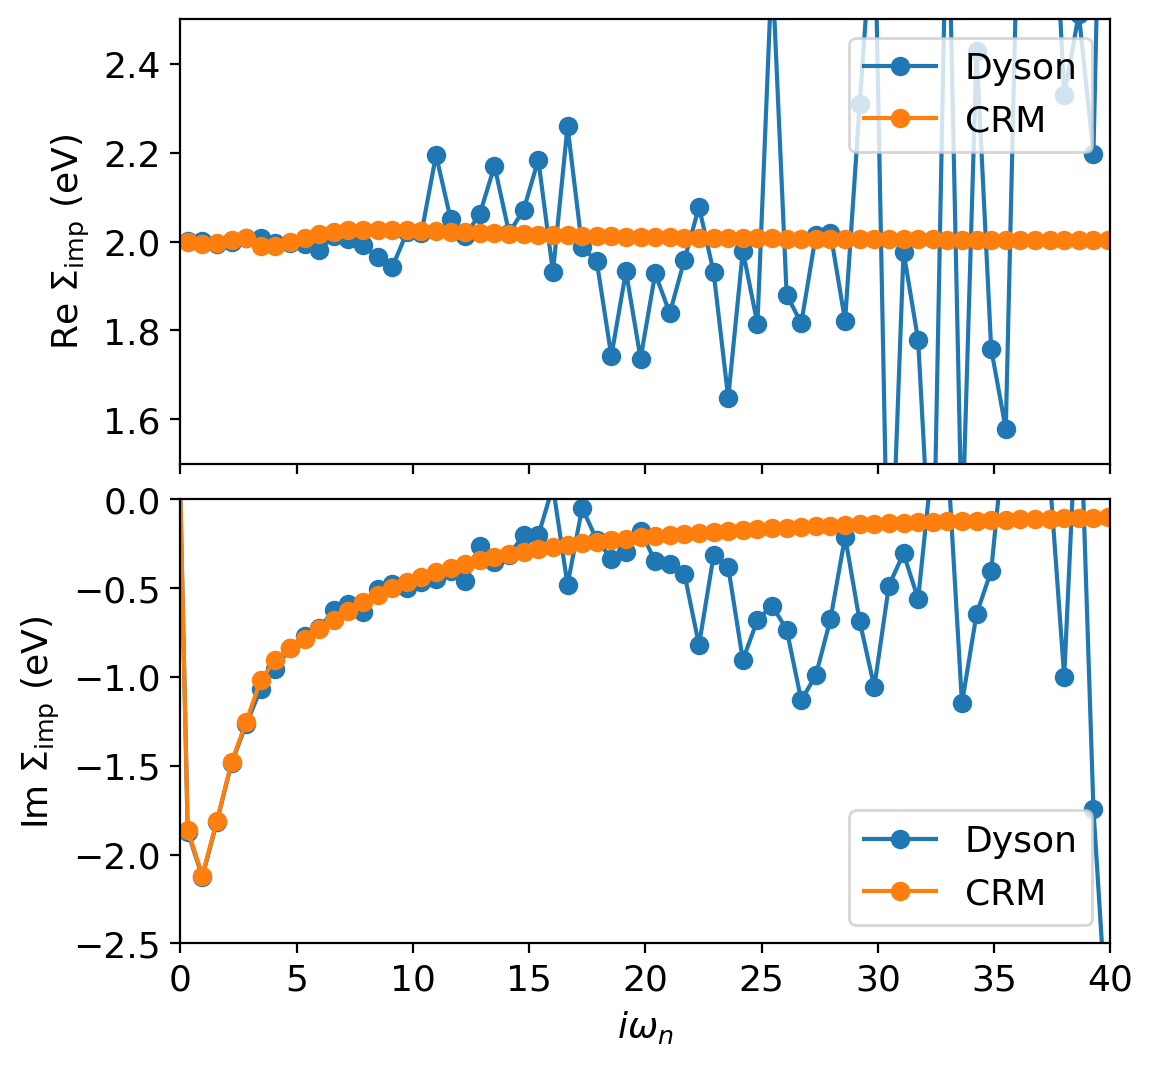

In [10]:
fig, ax = plt.subplots(2,1,dpi=200,figsize=(6,6),sharex=True)
ax = ax.reshape(-1)
fig.subplots_adjust(wspace=0.2, hspace=0.08)


ax[0].oplot(S_iw_dyson.real, '-o', label='Dyson')
ax[1].oplot(S_iw_dyson.imag, '-o', label='Dyson')

ax[0].oplot(S_iw_crm.real, '-o', label='CRM')
ax[1].oplot(S_iw_crm.imag, '-o', label='CRM')

ax[0].set_xlim(0,40)
ax[0].set_ylim(1.5,2.5)
ax[1].set_ylim(-2.5,0.)
ax[0].set_ylabel(r'Re $\Sigma_\mathrm{imp}$ (eV)')
ax[1].set_ylabel(r'Im $\Sigma_\mathrm{imp}$ (eV)')
ax[0].set_xlabel(r'')
ax[1].set_xlabel(r'$i \omega_n$')
ax[1].legend(loc='lower right')
plt.show()